Before running the notebook, add dataset: 
Go to File -> Add data.
Search for https://www.kaggle.com/datasets/grassknoted/asl-alphabet . 
Attach this file, the code will read from it using kaggle input 


Installed the timm library which is a collection of pytorch image models, including Vision Transformers
(For reference: https://github.com/huggingface/pytorch-image-models/tree/main/timm/models)

In [4]:
!pip install timm

Loaded the libraries required to train the model, handle the dataset and display our findings.

In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split
from google.colab import files
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision
import timm
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import numpy as np
import seaborn as sns

We begin by specifying the original dataset path and creating new directories for training and validation data if they do not already exist. Next, identifying all class folders (each ASL letter) and replicate these folders in both the train and validation directories.

We then segregate images for each class and split them into training (80%) and validations (20) sets. We then copy the training and validation images into their respective folders.

We set the image size to 128×128 and batch size to 32 and define a transformation pipeline to resize images, convert them to tensors, and normalize pixel values. Using ImageFolder, we create training and validation datasets with these transforms, then load them with DataLoader, shuffling training data for each epoch while keeping validation data order fixed. Finally, we extract class names, count the number of classes, and print the classes along with the sizes of the training and validation sets.

In [6]:
# Point to the folder that contains class directories
DATA_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"

BASE_DIR = os.path.join('/kaggle/working/', 'asl_dataset_new')
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Create train/val directories if they don't exist
if not os.path.exists(BASE_DIR):
    os.makedirs(TRAIN_DIR)
    os.makedirs(VAL_DIR)
    os.makedirs(TEST_DIR)

classes = os.listdir(DATA_DIR)

for cls in classes:
    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cls), exist_ok=True)
    
# standard 70/15/15 split for train/validation/test data
    images = os.listdir(os.path.join(DATA_DIR, cls))
    train_imgs, val_test_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(val_test_imgs, test_size=0.5, random_state=42)


    for img in train_imgs:
        shutil.copy(os.path.join(DATA_DIR, cls, img), os.path.join(TRAIN_DIR, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(DATA_DIR, cls, img), os.path.join(VAL_DIR, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(DATA_DIR, cls, img), os.path.join(TEST_DIR, cls, img))

print("Train/Validation split created successfully!")


Train/Validation split created successfully!


In [7]:
# image sizze set to 128 to reduce training time, as the pretrained ViT we are using expects input size 224 X 224
IMG_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_data = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_data = datasets.ImageFolder(VAL_DIR, transform=transform)
test_data =  datasets.ImageFolder(VAL_DIR, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


classes = train_data.classes
num_classes = len(classes)
print("Classes:", classes)
print("Train size:", len(train_data))
print("Val size:", len(val_data))
print('Test size:', len(test_data))


Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Train size: 60900
Val size: 13050
Test size: 13050


To have a look at few sample images from the first batch of training data loader created, we define a function in which we first reverse the normalization applied to the image earlier, convert the tensor back, display it with it’s title and remove the axis so it looks better. We then create an iterator for our data loader, load the first batch of data and unpack it into image tensors with their label, and the function defined takes these image tensors as input.

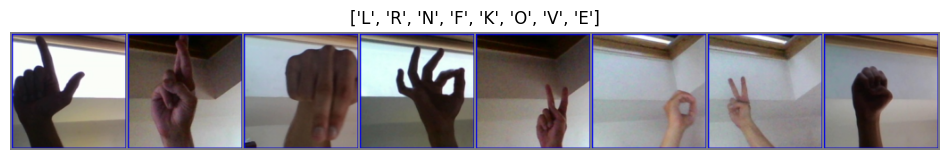

In [8]:
def sample_img_show(img, title):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy().transpose(1,2,0)
    plt.imshow(npimg)
    plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))
plt.figure(figsize=(12,6))
sample_img_show(torchvision.utils.make_grid(images[:8]), title=[classes[l] for l in labels[:8]])

We first check to see if we can use a GPU (CUDA), which we will use to train the PyTorch model since it’s much faster. If not we will have to use the CPU. According to us, it made more sense to use a pretrained Vision transformer model, rather than training from scratch. So, we set up the model, first by loading the pre-trained model vit_tiny_patch16_224 - Smallest ViT variant for faster training, adjusting the image size and using the pre-trained weights. We then replace the head which is the final classification layer and adapt it to our ASL classes. Finally moves the model to our GPU/CPU


Next we set up the loss function to measure how well our model performs, using crossentropyloss which is standard. We then set up the optimizer AdamW with a learning rate of 0.0001 to fine tune the model. We then print the models architecture.



Note: Initially, we used vit_base_patch16_224(huggingface, 2023a) – medium variant for ViT. However it has significantly great number of parameters (~ 85.8M) , due to which the it took a lot of time to train even for just a single epoch. But we could achieve same Train and Test accuracy with tiny variant (~ 9.7M), but was comparatively efficient and fast with training (huggingface, 2023b)


In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# vit_tiny_patch16_224
model = timm.create_model("vit_tiny_patch16_224", img_size=128, pretrained=True)
model.head = nn.Linear(model.head.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(model)

# Here we useAdamW as optimizer, instead of Adam. In AdamW weight decay is decoupled from gradient updates, preventing overfitting due to inneffective regularization.
# Papers like “An Image is Worth 16x16 Words” (ViT) and follow-up transformer papers always use AdamW.

Device: cuda


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


We define a train_epoch() function that sets the model to training mode, loops over the training data, moves inputs and labels to the device, performs forward and backward passes, updates weights, and tracks total loss and correct predictions, returning average loss and accuracy.

Similarly, the validate() function sets the model to evaluation mode, disables gradient updates, loops over validation data, computes loss and predictions, and returns the validation loss and accuracy.

In [10]:
def train_one_epoch():
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(train_loader), 100 * correct / total

def validate():
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return val_loss / len(val_loader), 100 * correct / total

We set the number of epochs and loop through each, training and validating the model while updating and printing performance metrics after every iteration.

In [11]:
EPOCHS = 3

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print("-"*50)


Epoch 1/3
Train Loss: 0.1151 | Train Acc: 96.72%
Val Loss:   0.0109 | Val Acc:   99.66%
--------------------------------------------------
Epoch 2/3
Train Loss: 0.0220 | Train Acc: 99.36%
Val Loss:   0.0258 | Val Acc:   99.18%
--------------------------------------------------
Epoch 3/3
Train Loss: 0.0212 | Train Acc: 99.39%
Val Loss:   0.0370 | Val Acc:   98.95%
--------------------------------------------------


We first initialize variables to store the true ASL labels and model predictions. The model is set to evaluation mode to prevent gradient updates while we loop through the validation loader, moving each batch to the device, obtaining predictions, selecting the class with the highest probability, and storing the results. Labels and predictions are moved to the CPU and converted to NumPy for analysis.


Finally, overall accuracy is computed by counting correct predictions, dividing by the total number of labels, converting to a percentage, and printing the result.

In [12]:
# --- Step 1: Collect all labels and predictions ---
all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# --- Step 2: Overall accuracy ---

accuracy = 100 * accuracy_score(all_labels, all_preds)
print(f'Test accuracy: {accuracy:.4f}%')


Test accuracy: 98.9502%


In [13]:
f1 =  f1_score(all_labels, all_preds, average='macro' )
print(f'F1 Score: {f1:.4f}')

F1 Score: 0.9896


Here we display a classification report, which displays the pecision, recall, f1-score, support results for each class and summing up the overall average for each metric.

In [14]:
# Classification report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))


Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       450
           B       0.98      1.00      0.99       450
           C       1.00      1.00      1.00       450
           D       1.00      1.00      1.00       450
           E       0.99      1.00      0.99       450
           F       1.00      1.00      1.00       450
           G       0.98      0.99      0.98       450
           H       1.00      0.97      0.98       450
           I       1.00      0.96      0.98       450
           J       1.00      0.99      0.99       450
           K       1.00      1.00      1.00       450
           L       1.00      1.00      1.00       450
           M       0.99      0.99      0.99       450
           N       1.00      0.98      0.99       450
           O       1.00      0.98      0.99       450
           P       0.85      1.00      0.92       450
           Q       1.00      1.00      1.00       450
  

Here we set up a confusion matrix visual to analyze our models performance in detail.

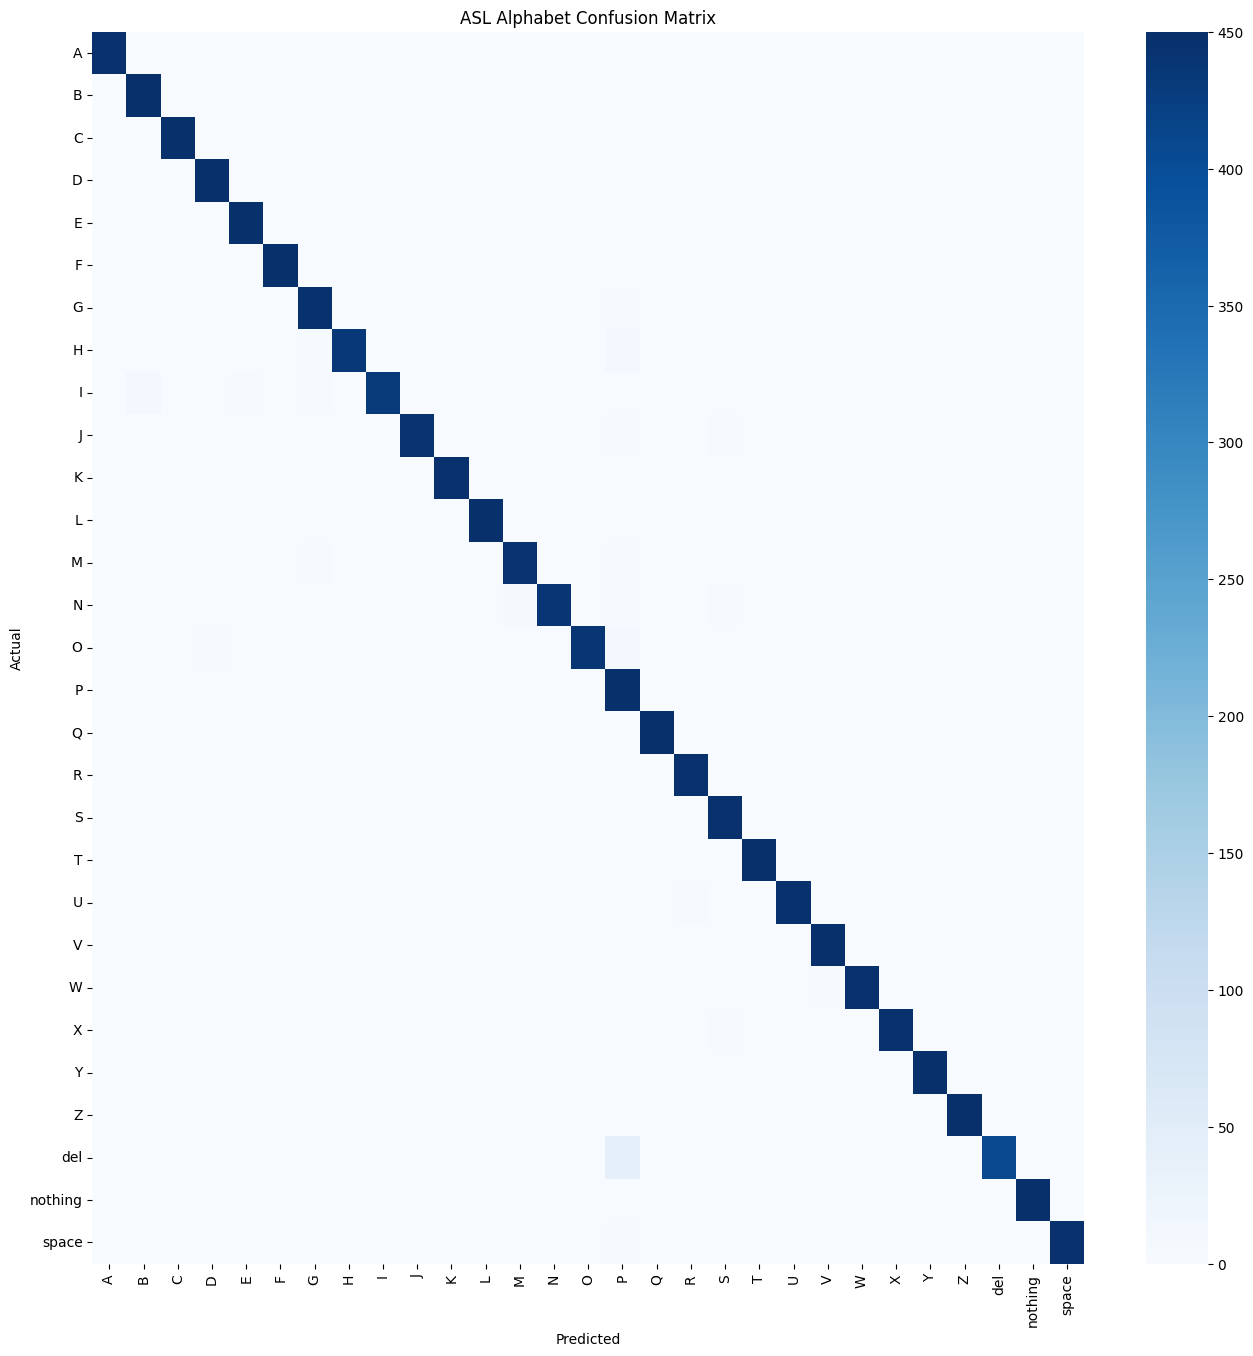

In [15]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16,16))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ASL Alphabet Confusion Matrix")
plt.show()

Here we calculate and display the accuracy for each class in our model

In [16]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for cls, acc in zip(classes, per_class_acc):
    print(f"{cls:10s}: {acc*100:.2f}%")

A         : 99.56%
B         : 99.78%
C         : 100.00%
D         : 100.00%
E         : 100.00%
F         : 100.00%
G         : 99.11%
H         : 96.67%
I         : 95.78%
J         : 98.67%
K         : 99.56%
L         : 100.00%
M         : 98.67%
N         : 97.78%
O         : 97.56%
P         : 100.00%
Q         : 100.00%
R         : 99.56%
S         : 99.56%
T         : 100.00%
U         : 98.89%
V         : 99.78%
W         : 99.33%
X         : 99.33%
Y         : 100.00%
Z         : 100.00%
del       : 90.44%
nothing   : 100.00%
space     : 99.56%


In [17]:
# To save our trained model
torch.save(model.state_dict(), "asl_vit_model_tiny.pth")
print("Model saved!")

Model saved!


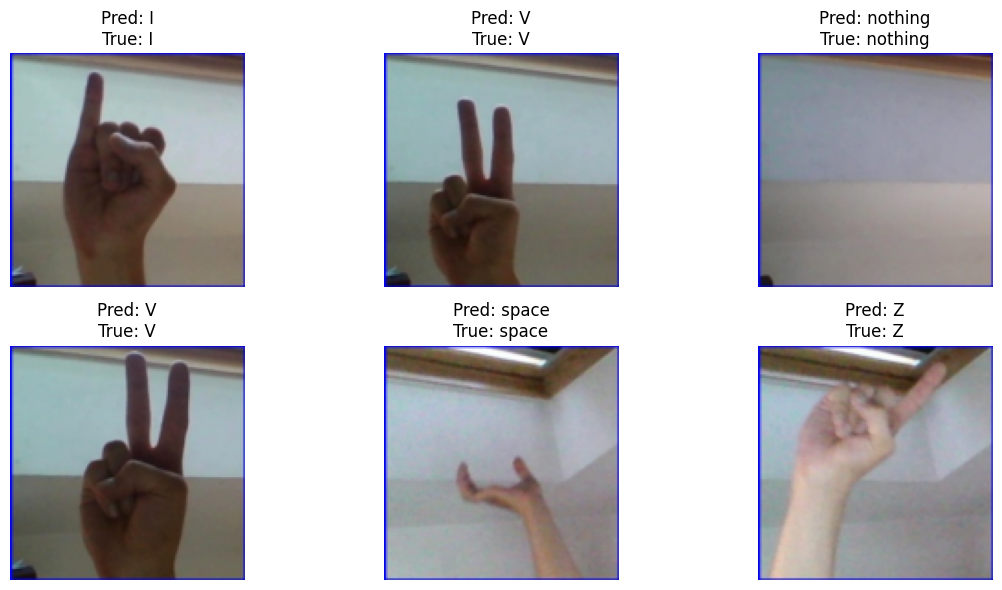

In [18]:
# Get a batch of test images
val_loader_vis = DataLoader(val_data, batch_size=32, shuffle=True)

dataiter = iter(val_loader_vis)  # you can also use a separate test_loader if available
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)

#  Model predictions 
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = outputs.max(1)

#  Display a few images with predictions 
def imshow(img, title):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.cpu().numpy().transpose((1, 2, 0))
    plt.imshow(npimg)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(12,6))
for i in range(6):  # show first 6 images
    plt.subplot(2, 3, i+1)
    imshow(images[i], title=f"Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}")
plt.tight_layout()
plt.show()